In [2]:

import pandas as pd

In [3]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(os.path.join(project_root, "src"))


In [4]:

from models.time_series_models import run_arima, run_sarima, run_holt_winters, run_prophet



In [6]:
df = pd.read_csv("../data/processed/merged_clean.csv", parse_dates=["datetime"])
client_id = df["client_id"].unique()[0]
df_client = df[df["client_id"] == client_id].sort_values("datetime")


df_daily = df_client.resample("D", on="datetime").mean(numeric_only=True).reset_index()
df_daily = df_daily.rename(columns={"datetime": "ds", "value": "y"}).dropna()
df_daily.head()


,ds,y
0,2012-10-13,0.230979
1,2012-10-14,0.275479
2,2012-10-15,0.213688
3,2012-10-16,0.203521
4,2012-10-17,0.226771


c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


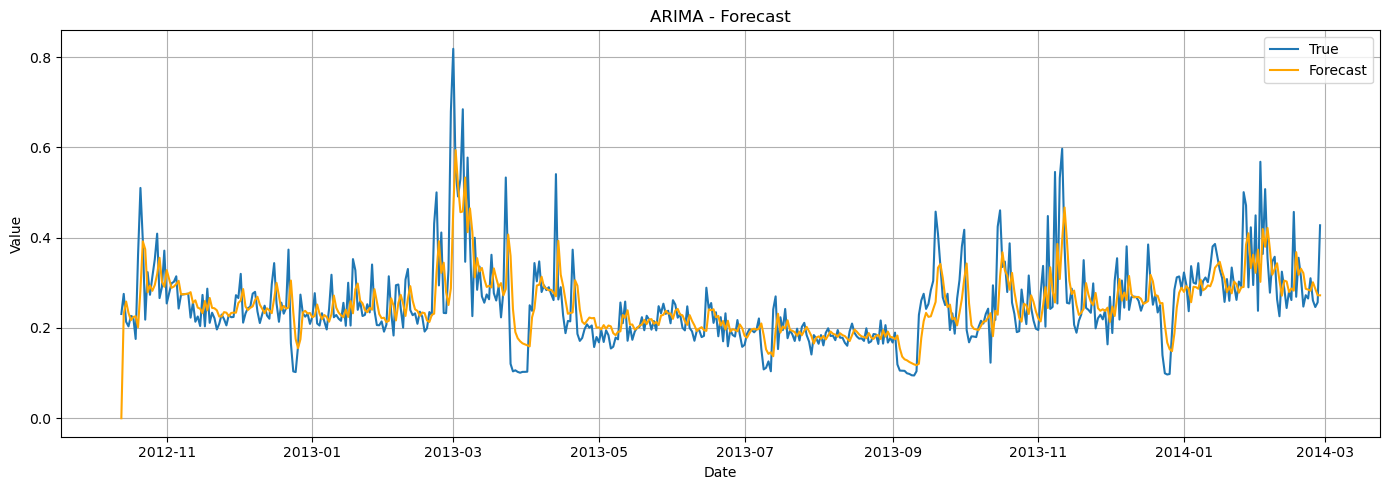

In [11]:
run_arima(df_daily, order=(2,1,2))


c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


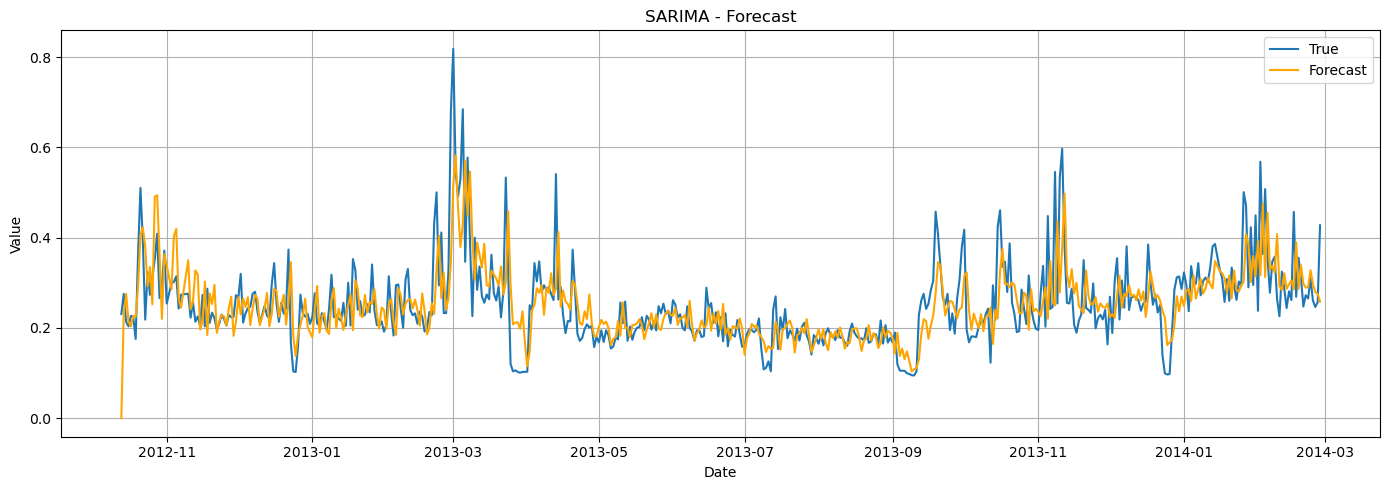

In [12]:
run_sarima(df_daily, order=(1,1,1), seasonal_order=(1,1,1,7))


c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


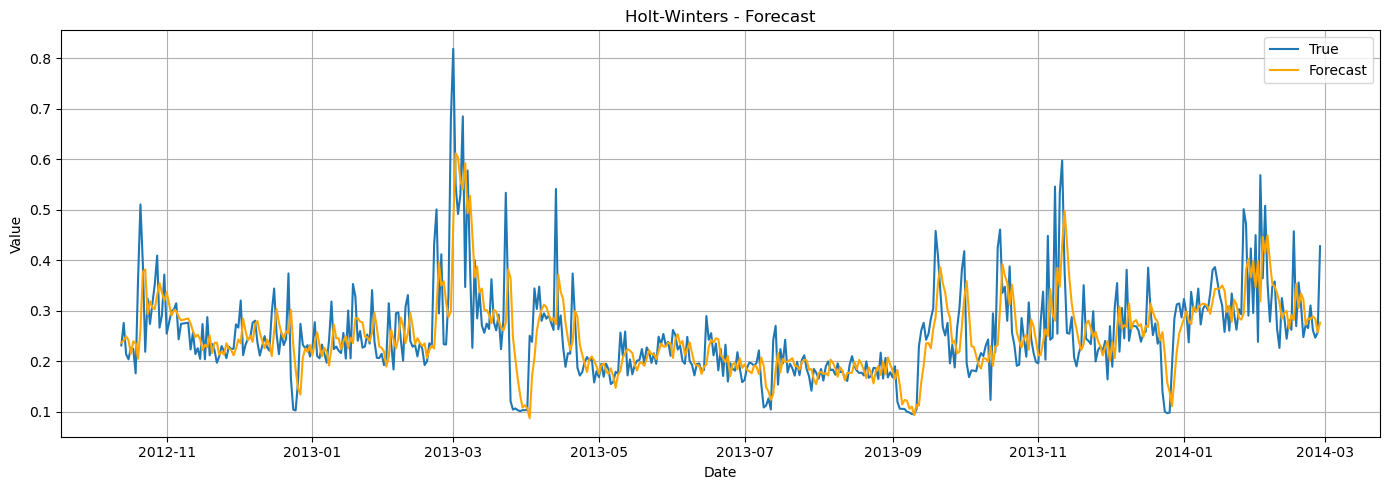

In [13]:
run_holt_winters(df_daily)


In [ ]:
#run_prophet(df_daily)
